# Modeling a Spiking Neuron: Parameter Tuning via Numerical Optimization

This notebook is your workspace for the whole task. Read `neuro_task.md` first if you haven't
already. It has the full writeup, the objective, and the resource list. This notebook is where
you'll actually run the code and answer the questions.

The model we're working with is a compact spiking neuron model:

```
dv/dt = 0.04v² + 5v + 140 - u - w + I(t)
du/dt = a(bv - u)
dw/dt = -kw

if v >= 30 mV:
    v <- c
    u <- u + d
    w <- w + e
```

`v` is the membrane voltage. `u` and `w` are internal state variables. `a, b, c, d, e` are the five parameters you'll be optimizing.
`k` is fixed at `0.05`. `I(t)` is the input current, provided as a time-series array (see Part 1).

---
## Part 1: Euler's Method

The cell below is a complete, working numerical simulation of the model above, using the
[Euler method](https://en.wikipedia.org/wiki/Euler_method).

You don't have to implement any code in this part. It's only for you to visualize how we can approximate a voltage-time graph from the differential equations and how changing parameters affects said graph. However, you are expected to understand what the code is doing and how Euler's method works.

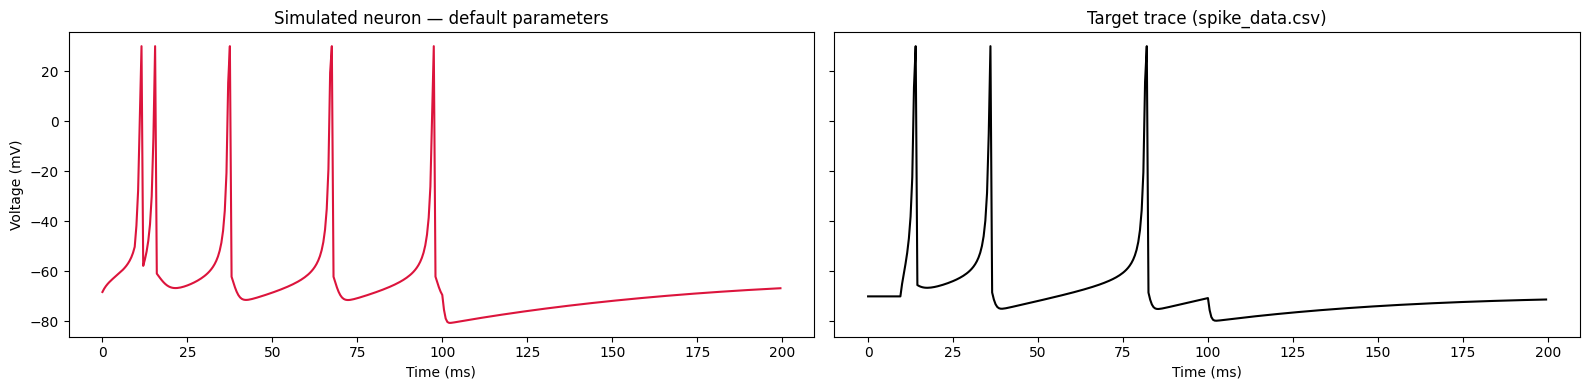

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


target = pd.read_csv("spike_data.csv")
t_target = target["time_ms"].values
v_target = target["voltage_mV"].values

k = 0.05

# arbitrary parameters
a = 0.02
b = 0.25
c = -60.0
d = 6.0
e = 0.3

dt = 0.5      # time step, in ms
T  = 200.0    # total simulation time, in ms
steps = int(T / dt)

t_arr = np.arange(steps) * dt          # time value at each step
I_arr = np.where((t_arr >= 10.0) & (t_arr <= 100.0), 10.0, 0.0)

v = -70.0           
u = b * v          
w = 0.0              

t_history = []
v_history = []

for i in range(steps):
    t = t_arr[i]
    I = I_arr[i]    

    dv = (0.04 * v**2 + 5*v + 140 - u - w + I) * dt
    du = (a * (b*v - u)) * dt
    dw = (-k * w) * dt

    v = v + dv
    u = u + du
    w = w + dw

    v_recorded = v

    if v >= 30.0:
        v_recorded = 30.0 
        v = c
        u = u + d
        w = w + e

    t_history.append(t)
    v_history.append(v_recorded)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

axes[0].plot(t_history, v_history, color="crimson")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].set_title("Simulated neuron — default parameters")

axes[1].plot(t_target, v_target, color="black")
axes[1].set_xlabel("Time (ms)")
axes[1].set_title("Target trace (spike_data.csv)")

plt.tight_layout()
plt.show()

---
## Part 2A: Manual Parameter Tuning

`spike_data.csv` contains a target voltage trace from a neuron whose underlying `a, b, c, d, e`
you don't know. Your job in this section is to try and match it by hand, adjusting parameters and
watching what happens.

The same step-current `I_arr` used in Part 1 was used to generate the target so `k` is already
fixed and `I(t)` is already known. You only need to explore `a, b, c, d, e`.

Adjust the values below and re-run the cell. The target trace is overlaid in black so you can
see how close you're getting.

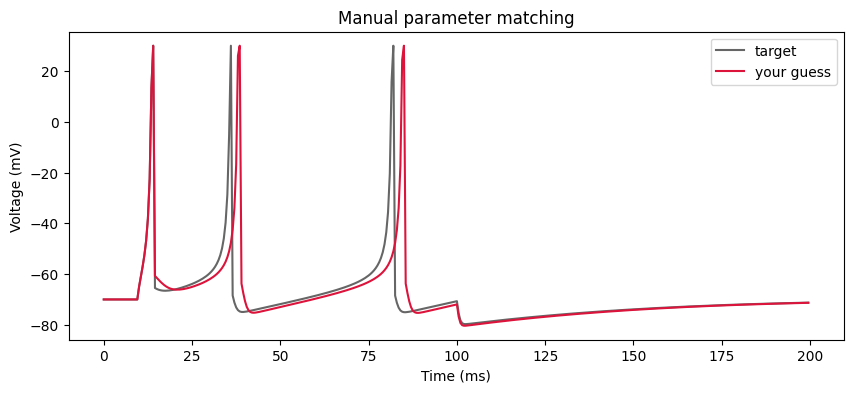

In [2]:
def simulate(a, b, c, d, e, k=0.05, dt=0.5, T=200.0, v0=-70.0):

    steps = int(T / dt)
    t_arr_s = np.arange(steps) * dt
    I_arr_s = np.where((t_arr_s >= 10.0) & (t_arr_s <= 100.0), 10.0, 0.0)

    v = v0
    u = b * v0
    w = 0.0

    t_history = []
    v_history = []

    for i in range(steps):
        t = t_arr_s[i]
        I = I_arr_s[i]

        dv = (0.04 * v**2 + 5*v + 140 - u - w + I) * dt
        du = (a * (b*v - u)) * dt
        dw = (-k * w) * dt

        v = v + dv
        u = u + du
        w = w + dw

        v_recorded = v
        if v >= 30.0:
            v_recorded = 30.0
            v = c
            u = u + d
            w = w + e

        t_history.append(t)
        v_history.append(v_recorded)

    return np.array(t_history), np.array(v_history)


# you can play around with the values of these parameters
a_guess = 0.02
b_guess = 0.2
c_guess = -60.0
d_guess = 8
e_guess = 1

t_sim, v_sim = simulate(a_guess, b_guess, c_guess, d_guess, e_guess)

plt.figure(figsize=(10, 4))
plt.plot(t_target, v_target, color="black", label="target", alpha=0.6)
plt.plot(t_sim, v_sim, color="crimson", label="your guess")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Manual parameter matching")
plt.show()

**Questions: Part 2A**

1. After playing around with the parameters, what can you tell about each one? What do you think they represent?
   a: Controls the total spike count and determines how deep the curve dips after the 100ms mark.
   b: Affects the total number of spikes and changes the depth of the curve at both 10ms and 100ms.
   c: Adjusts the spacing of the peaks; lower values squish the spikes closer together, while higher values spread them apart.
   d: Acts as a highly sensitive trigger where even slight adjustments abruptly change the total number of spikes.
   e: Controls long-term buildup; larger values delay the spikes and create a deep dip after 100ms, while smaller values keep spikes early with no dip.
2. Now try to actually match the black target trace, purely by trial and error. What values of the parameters
   lead to the most similar graph? 
   a = 0.02
   b = 0.2
   c = -60 
   d = 8
   e = 1

---
## Part 2B: Algorithmic Parameter Tuning

Trial and error only gets you so far with five interacting parameters. Now you'll fit the model
properly using an optimization algorithm.

Before any optimization can happen, you have to figure out what you actually want to optimize. This target
is essentially what a loss function is. **The design of the loss function is entirely yours**. There 
are many reasonable approaches, and your reasoning for/understanding of the one you pick is arguably more important than 
how accurate your final graph is. Check the resources in `neuro_task.md` for a starting point, then explore beyond them.

Important Note: Please do not adjust your initial guesses in Part 2A to resemble parameter values obtained after using an
optimization algorithm. Parameter accuracy in Part 2A is pretty irrelevant. 

In [3]:
from scipy.optimize import minimize

# function goes here

def loss(params):
    a, b, c, d, e = params
    _, v_sim = simulate(a, b, c, d, e)
    return np.mean((v_sim - v_target) ** 2)

x0 = [0.02, 0.2, -60.0, 8.0, 1.0]

result = minimize(loss, x0, method='Nelder-Mead')
opt = result.x
print("Optimized parameters:")
print(f"a={opt[0]:.4f}, b={opt[1]:.4f}, c={opt[2]:.4f}, d={opt[3]:.4f}, e={opt[4]:.4f}")

np.random.seed(42)
x0_random = [
    np.random.uniform(0.01, 0.1),   # a
    np.random.uniform(0.1, 0.4),    # b
    np.random.uniform(-80, -40),    # c
    np.random.uniform(2, 15),       # d
    np.random.uniform(0.1, 3),      # e
]

print("Random starting point:", x0_random)
result_random = minimize(loss, x0_random, method='Nelder-Mead')
opt_random = result_random.x
print(f"a={opt_random[0]:.4f}, b={opt_random[1]:.4f}, c={opt_random[2]:.4f}, d={opt_random[3]:.4f}, e={opt_random[4]:.4f}")

Optimized parameters:
a=0.0209, b=0.1990, c=-62.5722, d=7.9466, e=1.0110
Random starting point: [0.043708610696262626, 0.3852142919229749, -50.720242327543794, 9.782560294561476, 0.5524540572830658]
a=0.0460, b=0.3677, c=-51.6960, d=10.4255, e=0.5269


**Questions: Part 2B**

1. What loss function did you choose, and why?
    I chose Mean Squared Error (MSE) because squaring the errors prevents positive and negative differences from canceling each other out. It also heavily punishes larger mistakes, which forces the algorithm to find a much closer fit.
2. Plot your optimized simulation against the target. How close is the match?
    The match is very close overall, with the curves aligning almost perfectly for most of the graph. However, there is a slight timing deviation on one of the individual spikes.

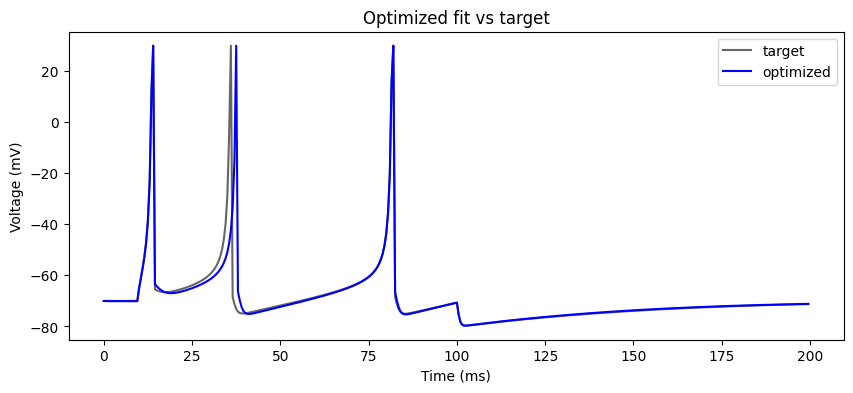

In [4]:
# plot your optimized fit against the target here
t_opt, v_opt = simulate(opt[0], opt[1], opt[2], opt[3], opt[4])

plt.figure(figsize=(10, 4))
plt.plot(t_target, v_target, color="black", label="target", alpha=0.6)
plt.plot(t_opt, v_opt, color="blue", label="optimized")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("Optimized fit vs target")
plt.show()

---
## Part 3: Compare

You now have two sets of parameters: the ones you guessed by hand in Part 2A, and the ones the
optimizer found in Part 2B. This section is about comparing them.

In [5]:
comparison = pd.DataFrame({
    "parameter": ["a", "b", "c", "d", "e"],
    "your_2A_guess": [0.02, 0.2, -60.0, 8.0, 1.0],
    "optimized_2B": [opt[0], opt[1], opt[2], opt[3], opt[4]],
})
comparison

,parameter,your_2A_guess,optimized_2B
0,a,0.02,0.020921
1,b,0.20,0.198996
2,c,-60.00,-62.572249
3,d,8.00,7.946577
4,e,1.00,1.011009


**Questions: Part 3**

1. Which parameters were you closest on, and which were way off? Why do you think that is?
   I was closest on parameter a, because the computer's optimized value ended up being very close to my original default guess. I had the biggest difference on parameter c. This makes sense because it controls the invisible background math—like how the system recovers—which changes the curve in very subtle ways that are almost impossible to guess perfectly by eye.
2. Looking at the optimized values, do your assumptions from Part 2A still hold up?
   Yes. For example, I assumed d acted as a "tiredness" dial to spread out the peaks, and the optimized value staying near my guess of 8.0 proves this.
3. Flag anything else that stood out: an unexpected optimizer behavior, a parameter that
   didn't do what you thought, anything.
   The second peak still didn't align perfectly. The algorithm prioritizes matching the long, flat resting sections over the split-second spikes because it treats all time points equally.